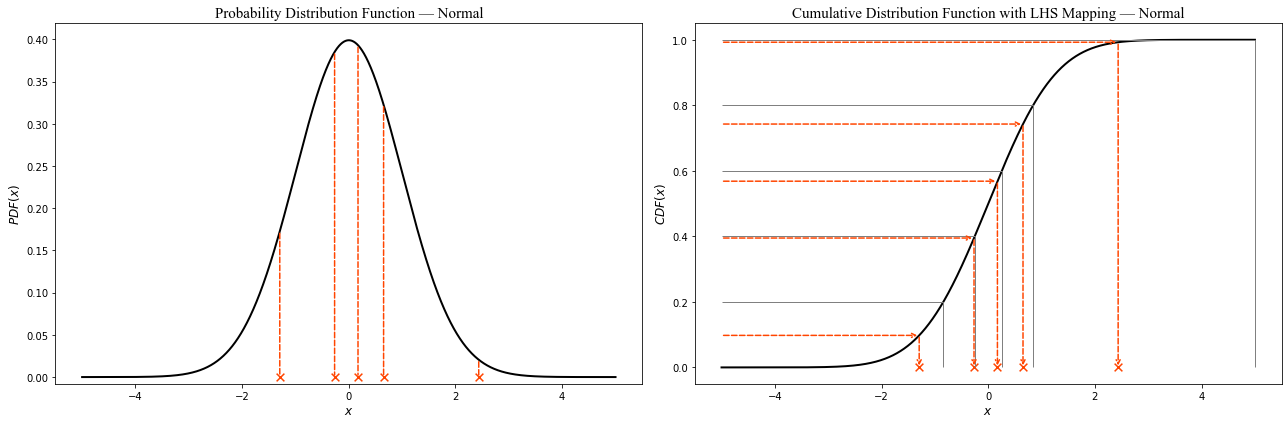

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from math import erf, sqrt

# ---------------------- USER TOGGLE / PARAMS ----------------------
dist_choice = 'normal'            # 'normal' | 'skewed_left_normal' | 'uniform'
n_strata    = 5                   # number of LHS strata/samples
rng = np.random.default_rng()     # unseeded => new subset each run

# Normal params
mu_norm, sigma_norm = 0.0, 1.0

# Skew-normal params (Azzalini), alpha < 0 => left-skewed
alpha_skew = -6.0
loc_skew, scale_skew = 0.0, 1.0

# Uniform params
a_uni, b_uni = -3.0, 3.0

# ---------------------- Helpers ----------------------
def std_normal_pdf(z):
    return (1.0 / np.sqrt(2.0*np.pi)) * np.exp(-0.5*z*z)

def std_normal_cdf(z):
    return 0.5 * (1.0 + erf(z / sqrt(2.0)))

def pdf_normal(x, mu, sigma):
    z = (x - mu) / sigma
    return std_normal_pdf(z) / sigma

def pdf_skew_normal(x, alpha, loc=0.0, scale=1.0):
    z = (x - loc) / scale
    return 2.0 * std_normal_pdf(z) * std_normal_cdf(alpha * z) / scale

def build_grid(choice):
    if choice == 'normal':
        low, high = mu_norm - 5*sigma_norm, mu_norm + 5*sigma_norm
    elif choice == 'skewed_left_normal':
        low, high = loc_skew - 8*scale_skew, loc_skew + 8*scale_skew
    elif choice == 'uniform':
        pad = 0.5*(b_uni - a_uni)
        low, high = a_uni - pad, b_uni + pad
    else:
        raise ValueError("Unknown choice")
    return np.linspace(low, high, 4000)

def make_pdf(choice, x):
    if choice == 'normal':
        pdf = pdf_normal(x, mu_norm, sigma_norm)
    elif choice == 'skewed_left_normal':
        pdf = pdf_skew_normal(x, alpha_skew, loc_skew, scale_skew)
    elif choice == 'uniform':
        pdf = np.zeros_like(x)
        mask = (x >= a_uni) & (x <= b_uni)
        pdf[mask] = 1.0 / (b_uni - a_uni)
    area = np.trapz(pdf, x)
    return pdf / area if area > 0 else pdf

def make_cdf_from_pdf(x, pdf):
    dx = np.diff(x)
    traps = 0.5*(pdf[:-1] + pdf[1:]) * dx
    cdf = np.zeros_like(x)
    cdf[1:] = np.cumsum(traps)
    cdf = np.clip(cdf, 0.0, 1.0)
    cdf[-1] = 1.0
    return cdf

def inv_cdf_sample(x, cdf, u):
    cdf_mono = np.maximum.accumulate(cdf)
    return np.interp(u, cdf_mono, x)

# ---------------------- Build distribution & LHS ----------------------
x   = build_grid(dist_choice)
pdf = make_pdf(dist_choice, x)
cdf = make_cdf_from_pdf(x, pdf)

edges     = np.linspace(0.0, 1.0, n_strata+1)
u_samples = edges[:-1] + rng.random(n_strata) * (edges[1:] - edges[:-1])
x_samples = inv_cdf_sample(x, cdf, u_samples)

xmin = x[0]
pdf_at_samples = np.interp(x_samples, x, pdf)

# ---------------------- Plot (side-by-side subplots) ----------------------
fig, axs = plt.subplots(1, 2, figsize=(18, 6))

# ---- Left: PDF ----
ax = axs[0]
ax.plot(x, pdf, color='black', linewidth=2)
for xs, ys in zip(x_samples, pdf_at_samples):
    ax.annotate("", xy=(xs, 0.0), xytext=(xs, ys),
                arrowprops=dict(arrowstyle='-', linestyle='--',
                                color='orangered', linewidth=1.5))
ax.scatter(x_samples, np.zeros_like(x_samples),
           marker='x', color='orangered', s=60)
ax.set_title(f"Probability Distribution Function — {dist_choice.replace('_', ' ').title()}", fontsize=15, fontname="Times New Roman")
ax.set_xlabel("$x$", fontsize=12, fontname="Times New Roman")
ax.set_ylabel("$PDF(x)$", fontsize=12, fontname="Times New Roman")
ax.set_ylim(-0.02 * pdf.max(), 1.05 * pdf.max())

# ---- Right: CDF ----
ax = axs[1]
ax.plot(x, cdf, color='black', linewidth=2)

# gray hlines/vlines that stop at the CDF
for e in edges:
    xe = inv_cdf_sample(x, cdf, e)
    ax.hlines(e, xmin, xe, colors='gray', linestyles='-', linewidth=1)
    ax.vlines(xe, 0.0, e, colors='gray', linestyles='-', linewidth=1)

# dashed orangered mapping arrows + x markers on input domain (y=0)
for u, xs in zip(u_samples, x_samples):
    ax.annotate("", xy=(xs, u), xytext=(xmin, u),
                arrowprops=dict(arrowstyle='->', linestyle='--',
                                color='orangered', linewidth=1.5))
    ax.annotate("", xy=(xs, 0.0), xytext=(xs, u),
                arrowprops=dict(arrowstyle='->', linestyle='--',
                                color='orangered', linewidth=1.5))
ax.scatter(x_samples, np.zeros_like(x_samples),
           marker='x', color='orangered', s=60)

ax.set_title(f"Cumulative Distribution Function with LHS Mapping — {dist_choice.replace('_', ' ').title()}", fontsize=15, fontname="Times New Roman")
ax.set_xlabel("$x$", fontsize=12, fontname="Times New Roman")
ax.set_ylabel("$CDF(x)$", fontsize=12, fontname="Times New Roman")
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()
